In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Show CVS data

In [ ]:

data_set = pd.read_csv("oasis_test_patients_metadata.csv")

print(data_set)

                ID M/F Hand  Age  Educ  SES  MMSE  CDR  eTIV   nWBV    ASF  \
0    OAS1_0001_MR1   F    R   74   2.0  3.0  29.0  0.0  1344  0.743  1.306   
1    OAS1_0003_MR1   F    R   73   4.0  3.0  27.0  0.5  1454  0.708  1.207   
2    OAS1_0004_MR1   M    R   28   NaN  NaN   NaN  NaN  1588  0.803  1.105   
3    OAS1_0005_MR1   M    R   18   NaN  NaN   NaN  NaN  1737  0.848  1.010   
4    OAS1_0006_MR1   F    R   24   NaN  NaN   NaN  NaN  1131  0.862  1.551   
..             ...  ..  ...  ...   ...  ...   ...  ...   ...    ...    ...   
239  OAS1_0156_MR2   F    R   20   NaN  NaN   NaN  NaN  1577  0.832  1.113   
240  OAS1_0202_MR2   F    R   23   NaN  NaN   NaN  NaN  1548  0.861  1.134   
241  OAS1_0230_MR2   F    R   19   NaN  NaN   NaN  NaN  1577  0.849  1.113   
242  OAS1_0249_MR2   F    R   28   NaN  NaN   NaN  NaN  1215  0.865  1.444   
243  OAS1_0395_MR2   F    R   26   NaN  NaN   NaN  NaN  1283  0.834  1.368   

     Delay             class  
0      NaN       NonDemented  
1

In [ ]:
print(data_set.info())
print(data_set.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      244 non-null    object 
 1   M/F     244 non-null    object 
 2   Hand    244 non-null    object 
 3   Age     244 non-null    int64  
 4   Educ    121 non-null    float64
 5   SES     116 non-null    float64
 6   MMSE    121 non-null    float64
 7   CDR     121 non-null    float64
 8   eTIV    244 non-null    int64  
 9   nWBV    244 non-null    float64
 10  ASF     244 non-null    float64
 11  Delay   10 non-null     float64
 12  class   244 non-null    object 
dtypes: float64(7), int64(2), object(4)
memory usage: 24.9+ KB
None
              ID M/F Hand  Age  Educ  SES  MMSE  CDR  eTIV   nWBV    ASF  \
0  OAS1_0001_MR1   F    R   74   2.0  3.0  29.0  0.0  1344  0.743  1.306   
1  OAS1_0003_MR1   F    R   73   4.0  3.0  27.0  0.5  1454  0.708  1.207   
2  OAS1_0004_MR1   M    R   28   NaN  NaN   

In [ ]:
print(data_set.isnull().sum())

ID         0
M/F        0
Hand       0
Age        0
Educ     123
SES      128
MMSE     123
CDR      123
eTIV       0
nWBV       0
ASF        0
Delay    234
class      0
dtype: int64


In [14]:
missing_counts = data_set.isnull().sum()

missing_percent = (missing_counts / len(data_set)) * 100

for col, pct in missing_percent.items():
    print(f"{col:10} {missing_counts[col]:5} missing ({pct:.1f}%)")

M/F            0 missing (0.0%)
Hand           0 missing (0.0%)
Age            0 missing (0.0%)
Educ         123 missing (50.4%)
SES          128 missing (52.5%)
MMSE         123 missing (50.4%)
CDR          123 missing (50.4%)
eTIV           0 missing (0.0%)
nWBV           0 missing (0.0%)
ASF            0 missing (0.0%)
class          0 missing (0.0%)


In [ ]:
duplicates = data_set.duplicated()
print(data_set[duplicates])
print(f"Number of duplicate rows:{duplicates.sum()}")

Empty DataFrame
Columns: [M/F, Hand, Age, Educ, SES, MMSE, CDR, eTIV, nWBV, ASF, class]
Index: []
Number of duplicate rows:0


### Izbacivanje nepotrebnoh polja ID Delay 

ID je samo indentifikator i nije potreban za dalji rad, dok Delay ima previše praznih polja.

In [ ]:
data_set = data_set.drop(['ID', 'Delay'], axis=1)

### Popunjavanje polja koji nemaju vrednosti medianom

In [16]:
for col in ['Educ', 'SES', 'MMSE', 'CDR']:
    data_set[col] = data_set[col].fillna(data_set[col].median())

In [19]:
print(data_set.isnull().sum())

M/F      0
Hand     0
Age      0
Educ     0
SES      0
MMSE     0
CDR      0
eTIV     0
nWBV     0
ASF      0
class    0
dtype: int64


### Label encoding

In [ ]:


le = LabelEncoder()

data_set['M/F'] = le.fit_transform(data_set['M/F'])   
data_set['Hand'] = le.fit_transform(data_set['Hand']) 
data_set['class'] = le.fit_transform(data_set['class']) 

In [24]:
print(data_set.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   M/F     244 non-null    int64  
 1   Hand    244 non-null    int64  
 2   Age     244 non-null    int64  
 3   Educ    244 non-null    float64
 4   SES     244 non-null    float64
 5   MMSE    244 non-null    float64
 6   CDR     244 non-null    float64
 7   eTIV    244 non-null    int64  
 8   nWBV    244 non-null    float64
 9   ASF     244 non-null    float64
 10  class   244 non-null    int64  
dtypes: float64(6), int64(5)
memory usage: 21.1 KB
None


### Korelaciona matrica

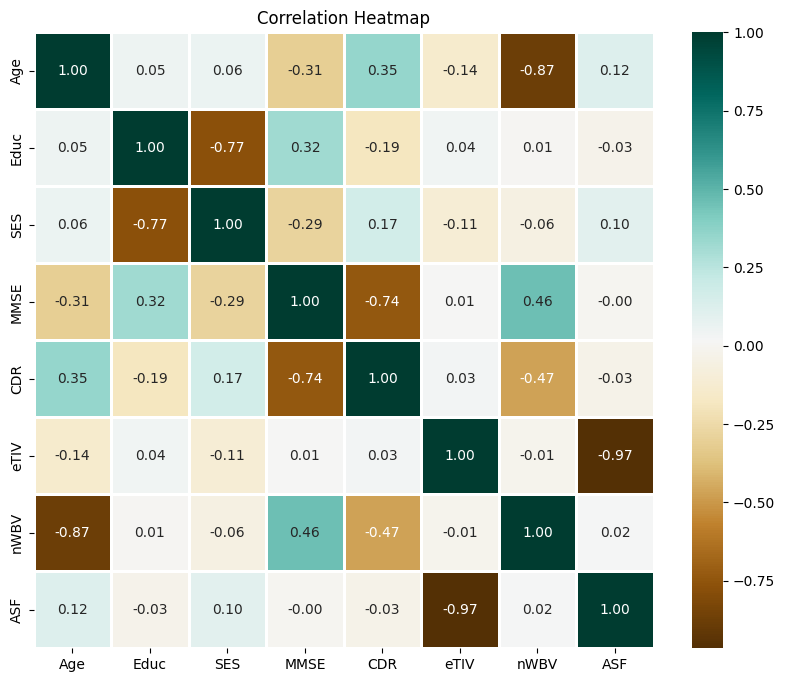

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Age','Educ','SES','MMSE','CDR','eTIV','nWBV','ASF']
plt.figure(figsize=(10,8))
sns.heatmap(data_set[num_cols].corr(), annot=True, fmt=".2f", cmap='BrBG', linewidths=1)
plt.title("Correlation Heatmap")
plt.show()


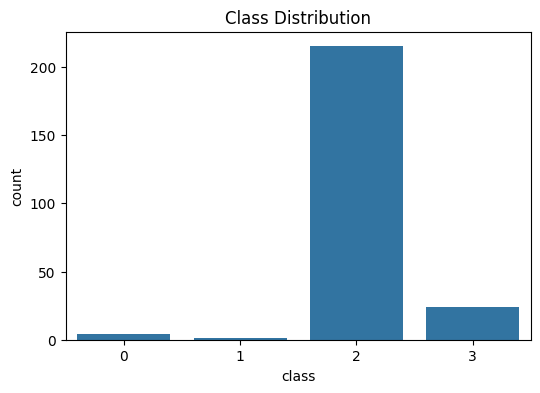

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=data_set)
plt.title("Class Distribution")
plt.show()